# HIFtool PSRT — CAVE Dataset Evaluation

In [1]:
# Downgrade PyTorch for P100 compatibility
!pip install torch==2.4.1 torchvision==0.19.1 --index-url https://download.pytorch.org/whl/cu121 -q
!pip install imgvision einops scipy timm --no-deps -q
!pip install timm -q
!git clone https://github.com/Nikesh0907/HIFtool.git /kaggle/working/HIFtool 2>/dev/null || true

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.9/798.9 MB 2.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 110.2 MB/s eta 0:00:0000:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 76.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 41.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 97.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.6 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 410.6/410.6 MB 4.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.6/121.6 MB 9.5 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.5/56.5 MB 33.3 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 124.2/124.2 MB 15.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 196.0/196.0 MB 2.0 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━

In [2]:
import os, sys, glob, argparse, time
import numpy as np, torch, torch.nn as nn
import scipy.io as sio, torch.utils.data as data
import matplotlib.pyplot as plt, imgvision as iv

HIFTOOL_DIR = '/kaggle/working/HIFtool'
sys.path.insert(0, HIFTOOL_DIR)

# Device with CUDA smoke test
device = 'cpu'
if torch.cuda.is_available():
    try:
        x = torch.randn(1,1,4,4).cuda()
        torch.nn.functional.interpolate(x, scale_factor=2, mode='bilinear')
        device = 'cuda'
        print(f'GPU OK: {torch.cuda.get_device_name()}')
    except Exception as e:
        print(f'GPU broken, using CPU')
print(f'Device: {device}  |  PyTorch: {torch.__version__}')

DATA_ROOT = '/kaggle/input/cave-dataset-2/Data'
CKPT_PATH = sorted(glob.glob('/kaggle/input/model-psrt/**/*.pth', recursive=True))[0]

all_mat = sorted(glob.glob(os.path.join(DATA_ROOT, '**', '*.mat'), recursive=True))
test_mats = [f for f in all_mat if '/Test/HSI/' in f]
print(f'Test HSI files: {len(test_mats)}')
print(f'Checkpoint: {CKPT_PATH}')

GPU OK: Tesla T4
Device: cuda  |  PyTorch: 2.4.1+cu121
Test HSI files: 12
Checkpoint: /kaggle/input/model-psrt/pytorch/default/1/1750.pth


In [3]:
def load_hsi(filepath):
    """Load CAVE .mat -> (H, W, 31) float64 in [0,1]"""
    try:
        d = sio.loadmat(filepath)
    except NotImplementedError:
        import h5py
        with h5py.File(filepath, 'r') as f:
            d = {k: np.array(f[k]) for k in f.keys()}
    if 'hsi' in d:
        gt = d['hsi'].astype(np.float64)
    elif 'HSI' in d:
        gt = d['HSI'].astype(np.float64)
    else:
        arrays = {k:v for k,v in d.items() if not k.startswith('__') and hasattr(v,'shape') and v.ndim>=2}
        gt = max(arrays.values(), key=lambda v: v.size).astype(np.float64)
    if gt.ndim == 3 and gt.shape[0] <= 31 and gt.shape[2] > 31:
        gt = gt.transpose(1, 2, 0)
    if gt.max() > 1.0:
        gt = gt / gt.max()
    return gt

sample = load_hsi(test_mats[0])
print(f'Verified: {os.path.basename(test_mats[0])} -> {sample.shape} ✓')

Verified: jelly_beans.mat -> (512, 512, 31) ✓


## Build PSRT model

In [4]:
from Networks.PSRT.net import PSRTnet

# PSRT config — bypass argparse
opt = argparse.Namespace(
    sf=32,
    patch_size=32 * 5,   # 160 — default from config.py
    msi_channel=3,       # CAVE uses 3-channel RGB
    hsi_channel=31,      # CAVE has 31 spectral bands
    n_bands=31,
    clip_max_norm=10,
    lr=1e-4,
)

model = PSRTnet(opt).to(device)
print(f'PSRT params: {sum(p.numel() for p in model.parameters()):,}')

# Load weights
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
sd = ckpt.get('net', ckpt) if isinstance(ckpt, dict) else ckpt
sd = {k.replace('module.', ''): v for k, v in sd.items()}
m, u = model.load_state_dict(sd, strict=False)
print(f'Loaded | missing:{len(m)} unexpected:{len(u)}')
if m: print(f'  Missing keys: {m[:5]}')
if u: print(f'  Unexpected keys: {u[:5]}')
model.eval()
print('PSRT ready ✓')

PSRT params: 247,455
Loaded | missing:0 unexpected:0
PSRT ready ✓


/usr/local/lib/python3.12/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)


## Prepare data

In [5]:
def getGk(ksize, sigma):
    x = torch.arange(-(ksize-1)//2, (ksize-1)//2+1)
    k = torch.exp(-0.5*(x/sigma)**2); k /= k.sum()
    return k.view(-1, 1).float()

class SpaDown(nn.Module):
    def __init__(self, sf):
        super().__init__()
        k = getGk(sf, sf/1.5); k = k @ k.T
        self.down = nn.Conv2d(1, 1, sf, sf, bias=False)
        self.down.weight.data[0, 0] = k
        self.down.requires_grad_(False)
    def forward(self, x):
        return self.down(x.transpose(1, 0)).transpose(1, 0)

SRF = np.load(os.path.join(HIFTOOL_DIR, 'Dataloader_tool', 'srflib', 'NikonD700.npy'))
print(f'SRF: {SRF.shape}')

class CAVEDataset(data.Dataset):
    def __init__(self, mat_paths, sf, srf):
        self.HR, self.LR, self.MSI, self.names = [], [], [], []
        sp = SpaDown(sf)
        for fp in mat_paths:
            gt = load_hsi(fp)
            gt31 = gt[:, :, :srf.shape[0]]
            lr = sp(torch.tensor(gt31.T).unsqueeze(0).float())[0].permute(2, 1, 0).numpy()
            msi = gt31 @ srf
            self.HR.append(gt31); self.LR.append(lr); self.MSI.append(msi)
            self.names.append(os.path.splitext(os.path.basename(fp))[0])
            print(f'  {self.names[-1]}: {gt31.shape}')
    def __getitem__(self, i):
        return (torch.FloatTensor(self.HR[i].transpose(2,0,1)),
                torch.FloatTensor(self.LR[i].transpose(2,0,1)),
                torch.FloatTensor(self.MSI[i].transpose(2,0,1)))
    def __len__(self): return len(self.HR)

print(f'Building dataset from {len(test_mats)} HSI files...')
ds = CAVEDataset(test_mats, opt.sf, SRF)
loader = data.DataLoader(ds, batch_size=1, shuffle=False)
print(f'Dataset: {len(ds)} images ✓')

SRF: (31, 3)
Building dataset from 12 HSI files...
  jelly_beans: (512, 512, 31)
  oil_painting: (512, 512, 31)
  paints: (512, 512, 31)
  photo_and_face: (512, 512, 31)
  pompoms: (512, 512, 31)
  real_and_fake_apples: (512, 512, 31)
  real_and_fake_peppers: (512, 512, 31)
  sponges: (512, 512, 31)
  stuffed_toys: (512, 512, 31)
  superballs: (512, 512, 31)
  thread_spools: (512, 512, 31)
  watercolors: (512, 512, 31)
Dataset: 12 images ✓


## Run PSRT evaluation

In [6]:
out_dir = '/kaggle/working/results_psrt'
os.makedirs(out_dir, exist_ok=True)
results, times = [], []

model.eval()
with torch.no_grad():
    for it, (GT_t, LR_t, MSI_t) in enumerate(loader, 1):
        # PSRT forward: model(lms, rgb)
        # lms = low-res HSI (B, 31, h, w)
        # rgb = high-res MSI (B, 3, H, W)
        LR_t = LR_t.to(device)
        MSI_t = MSI_t.to(device)

        t1 = time.time()
        out = model(LR_t, MSI_t)
        t2 = time.time()
        times.append(t2 - t1)

        pred = out[0].cpu().permute(1, 2, 0).numpy()
        gt = GT_t[0].permute(1, 2, 0).numpy()
        name = ds.names[it - 1]

        print(f'\n--- {it}/{len(ds)} [{name}] ({t2-t1:.2f}s) ---')
        iv.spectra_metric(pred, gt).Evaluation()

        np.save(f'{out_dir}/{name}_recon.npy', pred)
        results.append({'name': name, 'pred': pred, 'gt': gt})

print(f'\nDone | {len(results)} images | avg {np.mean(times):.3f}s')

/kaggle/working/HIFtool/Networks/PSRT/net.py:372: UserWarning: `nn.functional.upsample` is deprecated. Use `nn.functional.interpolate` instead.
  lms = nn.functional.upsample(lms, scale_factor=self.args.sf, mode='bicubic')



--- 1/12 [jelly_beans] (0.82s) ---
0	34.54907295547982	9.424013137817383	0.9930481314659119	0.9905670881271362	0.020046653226017952	0.9359904527664185

--- 2/12 [oil_painting] (0.02s) ---
0	38.0367021654928	7.48008918762207	0.7741338610649109	0.9924238324165344	0.012775182723999023	0.9248067140579224

--- 3/12 [paints] (0.02s) ---
0	35.23185910074712	7.579315185546875	0.7049566507339478	0.9929630756378174	0.019592175260186195	0.8942219614982605

--- 4/12 [photo_and_face] (0.02s) ---
0	41.0068315648537	11.605141639709473	1.1212785243988037	0.994113028049469	0.009438049048185349	0.8027993440628052

--- 5/12 [pompoms] (0.02s) ---
0	36.66436324705395	6.480663776397705	0.6389378309249878	0.9905014038085938	0.015363957732915878	0.953204870223999

--- 6/12 [real_and_fake_apples] (0.02s) ---
0	45.6088631727413	5.742983341217041	0.8060051798820496	0.9968502521514893	0.005708498880267143	0.9394450187683105

--- 7/12 [real_and_fake_peppers] (0.02s) ---
0	44.02154888762498	4.9992899894714355	0.56

/usr/local/lib/python3.12/dist-packages/imgvision/__init__.py:444: RuntimeWarning: invalid value encountered in divide
  A = np.sum(self.x1_ * self.x2_, axis=-1) / (


0	36.43395939207398	nan	0.3358355462551117	0.9968542456626892	0.015418319031596184	nan

Done | 12 images | avg 0.084s


/usr/local/lib/python3.12/dist-packages/imgvision/__init__.py:491: RuntimeWarning: invalid value encountered in divide
  CC = up.T / down.T


In [9]:
# ============ RESULTS SUMMARY TABLE ============
from skimage.metrics import structural_similarity as ssim
from skimage.metrics import peak_signal_noise_ratio as psnr

print('=' * 90)
print(f'{"PSRT Results Summary":^90}')
print('=' * 90)
print(f'{"Image":<25} {"PSNR (dB)":>10} {"SSIM":>10} {"SAM":>10} {"RMSE":>10} {"ERGAS":>10}')
print('-' * 90)

all_psnr, all_ssim, all_sam, all_rmse, all_ergas = [], [], [], [], []

for r in results:
    gt = r['gt']
    pred = r['pred']

    p = psnr(gt, pred, data_range=1.0)

    s_vals = [ssim(gt[:,:,b], pred[:,:,b], data_range=1.0) for b in range(gt.shape[-1])]
    s = np.mean(s_vals)

    gt_flat = gt.reshape(-1, gt.shape[-1])
    pred_flat = pred.reshape(-1, pred.shape[-1])
    dot = np.sum(gt_flat * pred_flat, axis=1)
    norm_gt = np.linalg.norm(gt_flat, axis=1)
    norm_pred = np.linalg.norm(pred_flat, axis=1)
    cos_angle = np.clip(dot / (norm_gt * norm_pred + 1e-10), -1, 1)
    sam_val = np.mean(np.arccos(cos_angle)) * 180 / np.pi

    rmse_val = np.sqrt(np.mean((gt - pred) ** 2))

    H, W, C = gt.shape
    sf = opt.sf
    band_rmse = [np.sqrt(np.mean((gt[:,:,b] - pred[:,:,b])**2)) for b in range(C)]
    band_mean = [np.mean(gt[:,:,b]) + 1e-10 for b in range(C)]
    ergas = 100 / sf * np.sqrt(np.mean([(br/bm)**2 for br, bm in zip(band_rmse, band_mean)]))

    all_psnr.append(p); all_ssim.append(s); all_sam.append(sam_val)
    all_rmse.append(rmse_val); all_ergas.append(ergas)

    print(f'{r["name"]:<25} {p:>10.4f} {s:>10.4f} {sam_val:>10.4f} {rmse_val:>10.6f} {ergas:>10.4f}')

print('-' * 90)
print(f'{"AVERAGE":<25} {np.mean(all_psnr):>10.4f} {np.mean(all_ssim):>10.4f} {np.mean(all_sam):>10.4f} {np.mean(all_rmse):>10.6f} {np.mean(all_ergas):>10.4f}')
print(f'{"STD":<25} {np.std(all_psnr):>10.4f} {np.std(all_ssim):>10.4f} {np.std(all_sam):>10.4f} {np.std(all_rmse):>10.6f} {np.std(all_ergas):>10.4f}')
print('=' * 90)


                                   PSRT Results Summary                                   
Image                      PSNR (dB)       SSIM        SAM       RMSE      ERGAS
------------------------------------------------------------------------------------------
jelly_beans                  33.9592     0.9480     9.4240   0.020047     0.4966
oil_painting                 37.8727     0.9524     7.4801   0.012775     0.3871
paints                       34.1583     0.9667     7.5793   0.019592     0.3525
photo_and_face               40.5024     0.9713    11.6052   0.009438     0.5606
pompoms                      36.2699     0.9516     6.4807   0.015364     0.3195
real_and_fake_apples         44.8696     0.9847     5.7430   0.005708     0.4031
real_and_fake_peppers        43.1775     0.9823     4.9993   0.006936     0.2819
sponges                      36.2814     0.9697     4.4583   0.015344     0.2436
stuffed_toys                 37.0829     0.9616     9.3864   0.013991     0.3772
superbal

## Visualize

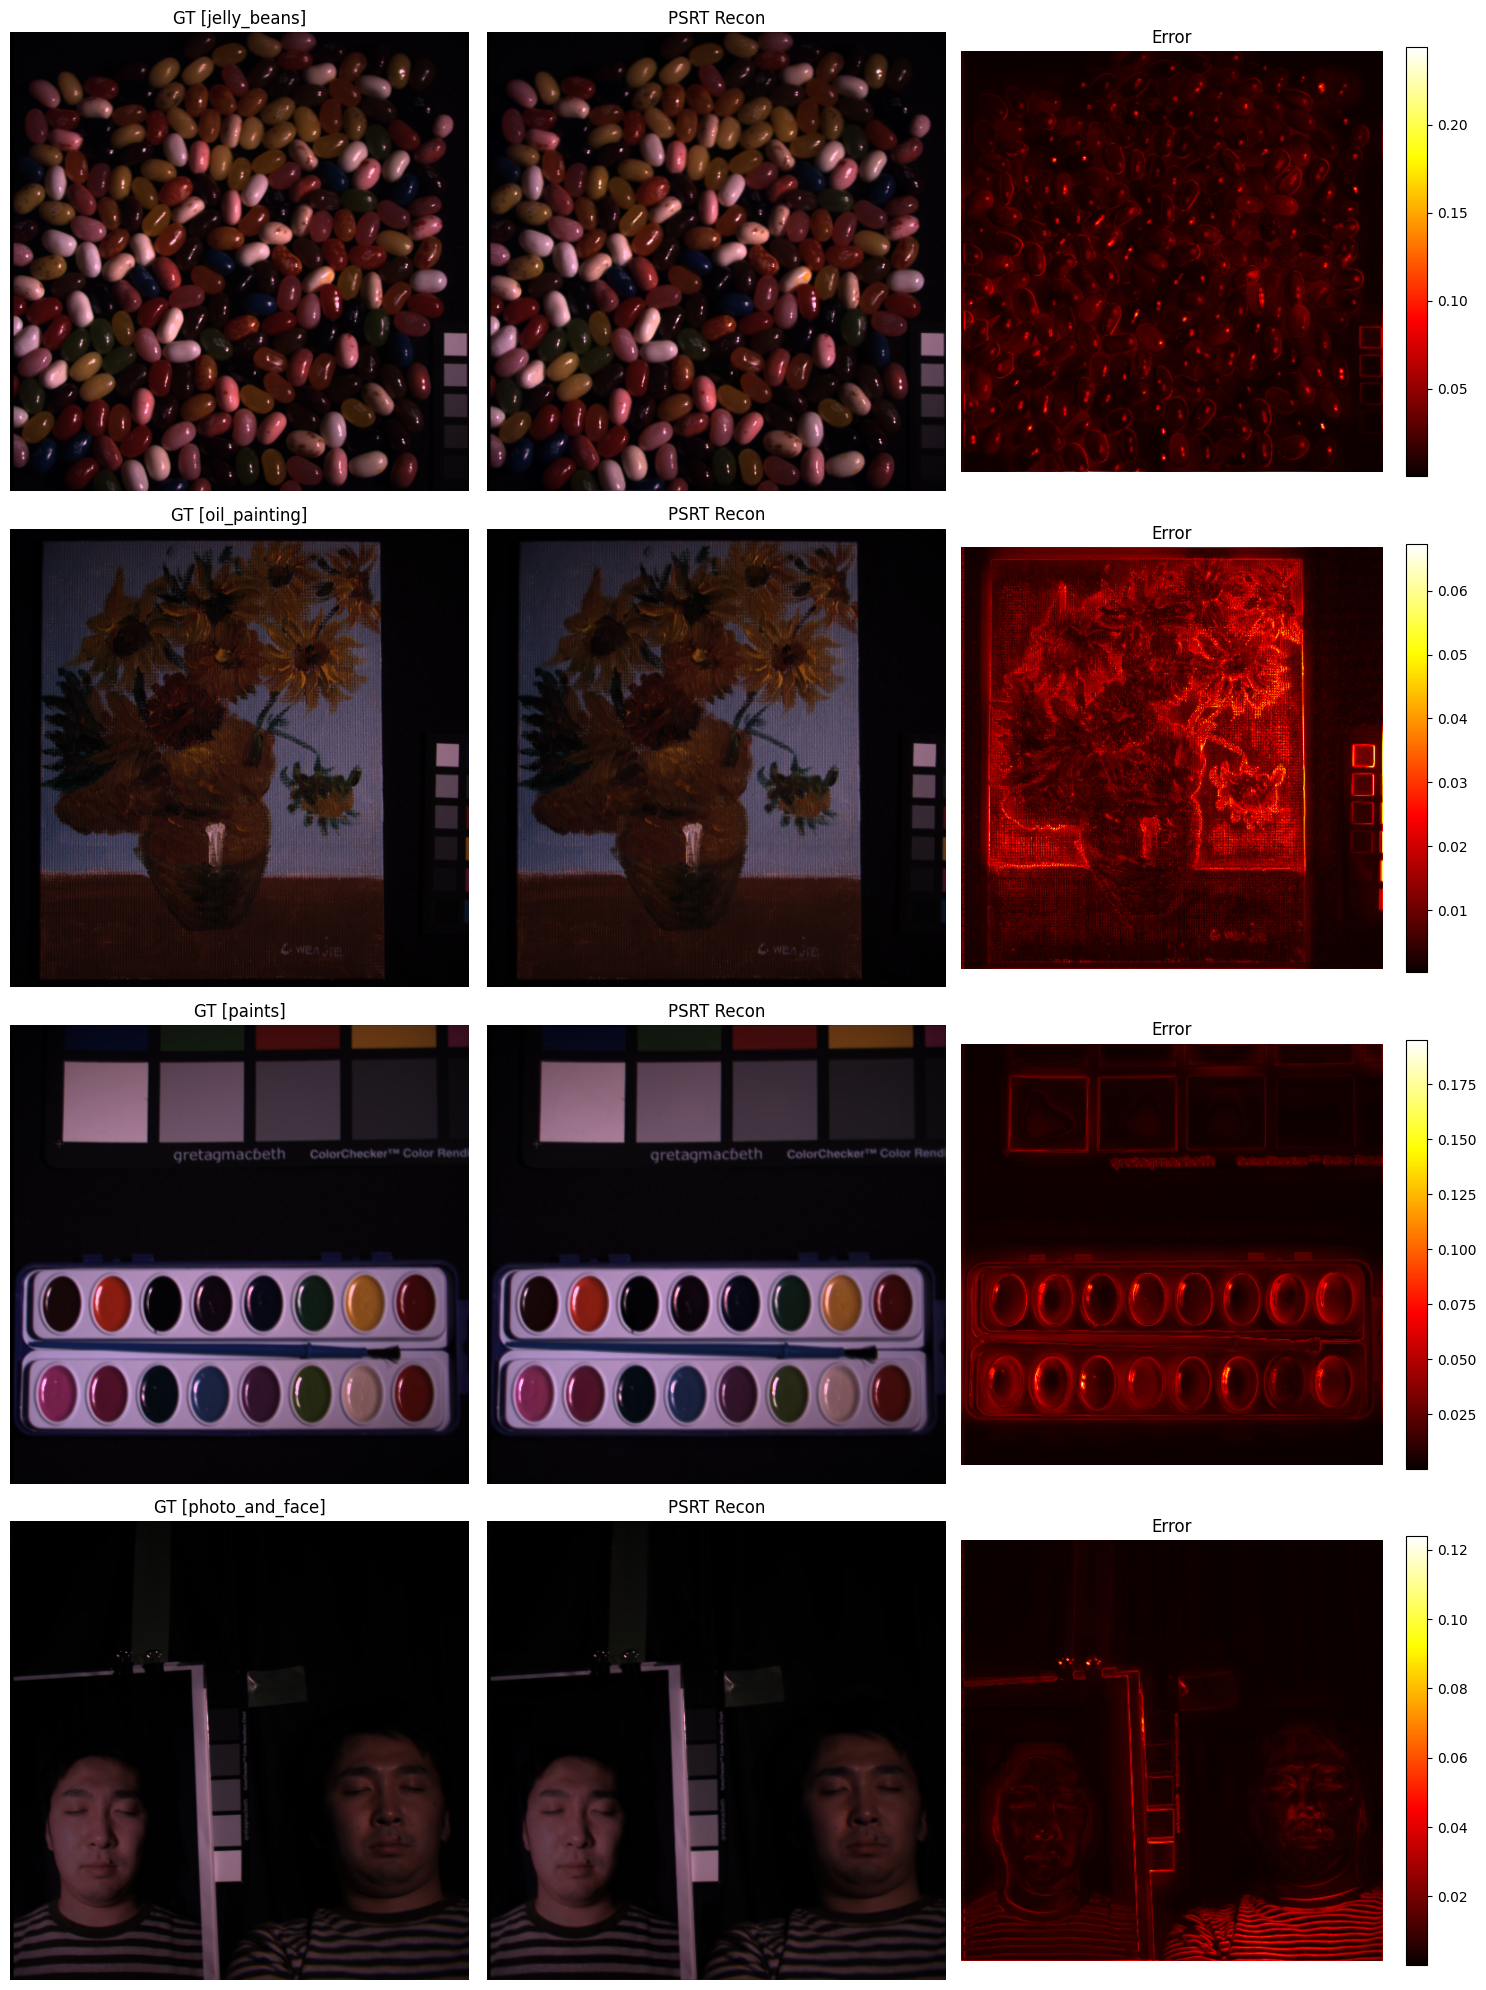

In [7]:
def to_rgb(h): return np.clip(h @ SRF, 0, 1)
n = min(4, len(results))
fig, ax = plt.subplots(n, 3, figsize=(15, 5*n))
if n == 1: ax = ax[np.newaxis, :]
for i in range(n):
    r = results[i]
    ax[i,0].imshow(to_rgb(r['gt']));   ax[i,0].set_title(f'GT [{r["name"]}]'); ax[i,0].axis('off')
    ax[i,1].imshow(to_rgb(r['pred'])); ax[i,1].set_title('PSRT Recon');        ax[i,1].axis('off')
    im = ax[i,2].imshow(np.abs(r['gt']-r['pred']).mean(-1), cmap='hot')
    ax[i,2].set_title('Error'); ax[i,2].axis('off')
    plt.colorbar(im, ax=ax[i,2], fraction=0.046)
plt.tight_layout(); plt.savefig('/kaggle/working/psrt_vis.png', dpi=150); plt.show()

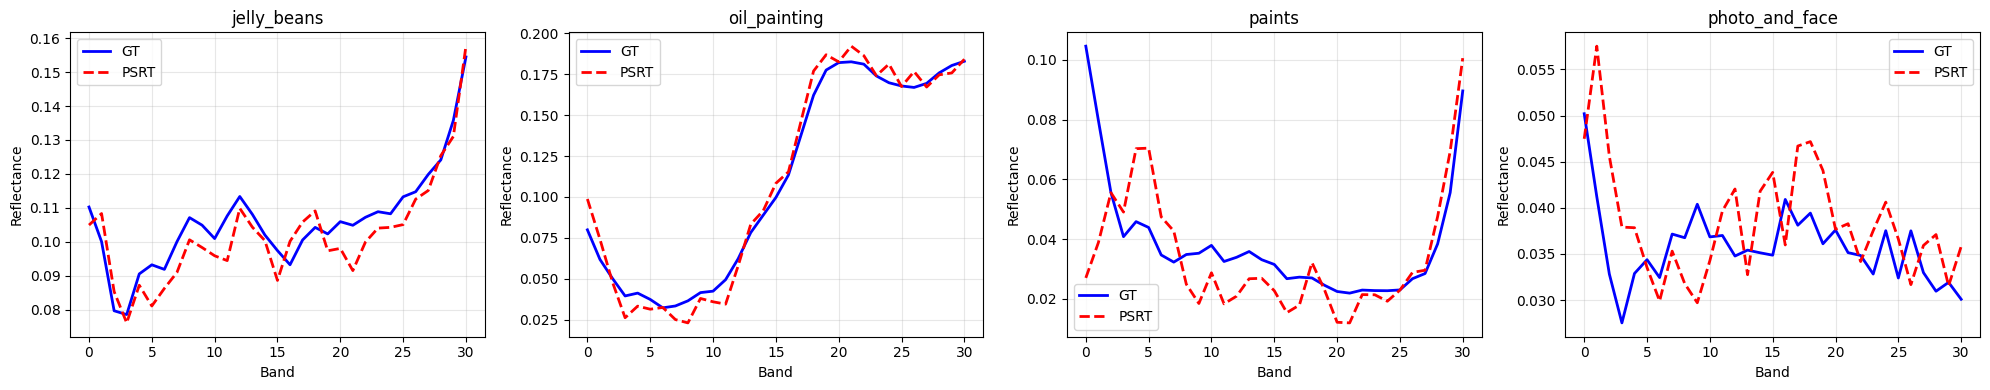

In [8]:
# Spectral profile comparison
n = min(4, len(results))
fig, ax = plt.subplots(1, n, figsize=(5*n, 4))
if n == 1: ax = [ax]
for i in range(n):
    r = results[i]; H,W = r['gt'].shape[:2]; cy,cx = H//2, W//2
    ax[i].plot(r['gt'][cy,cx,:], 'b-', label='GT', lw=2)
    ax[i].plot(r['pred'][cy,cx,:], 'r--', label='PSRT', lw=2)
    ax[i].set_title(r['name']); ax[i].legend(); ax[i].grid(alpha=0.3)
    ax[i].set_xlabel('Band'); ax[i].set_ylabel('Reflectance')
plt.tight_layout(); plt.show()